In [1]:
# Install required libraries
!pip install albumentations timm torchmetrics --quiet

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics import F1Score, ConfusionMatrix

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
   GPU: Tesla P100-PCIE-16GB


In [9]:
class CFG:
    # ── Paths ──────────────────────────────────────────────────────────────
    DATA_DIR        = '/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data'               # Root data directory
    TRAIN_CSV       = '/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/train.csv'     # Columns: filename, label
    TEST_CSV        = '/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/test.csv'      # Columns: filename, label
    FRAMES_DIR      = './frames'             # Where extracted frames are saved
    CHECKPOINT_DIR  = './checkpoints'        # Model checkpoints
    
    # ── Frame Extraction ──────────────────────────────────────────────────
    NUM_FRAMES      = 16      # Frames sampled per video (evenly spaced)
    IMG_SIZE        = 224     # Resize to 224×224
    
    # ── Training ──────────────────────────────────────────────────────────
    NUM_CLASSES     = 14
    BATCH_SIZE      = 32
    NUM_WORKERS     = 2

    # Warm-up phase (only FC head trained)
    WARMUP_EPOCHS   = 8
    WARMUP_LR       = 1e-3

    # Fine-tune phase (last 2 blocks + FC unfrozen)
    FINETUNE_EPOCHS = 20
    FINETUNE_LR     = 1e-4

    # Full fine-tune (optional — all layers)
    FULL_FT_EPOCHS  = 8
    FULL_FT_LR      = 1e-5

    WEIGHT_DECAY    = 1e-4
    DROPOUT         = 0.4

    # ── Class Names ───────────────────────────────────────────────────────
    CLASS_NAMES = [
        'abuse', 'arrest', 'arson', 'assault', 'burglary',
        'explosion', 'fighting', 'normal', 'road_accident',
        'robbery', 'shooting', 'shoplifting', 'stealing', 'vandalism'
    ]
    CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}
    IDX_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_IDX.items()}

# Create output directories
for d in [CFG.FRAMES_DIR, CFG.CHECKPOINT_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print('Configuration loaded.')
print(f'   Classes ({CFG.NUM_CLASSES}): {CFG.CLASS_NAMES}')

Configuration loaded.
   Classes (14): ['abuse', 'arrest', 'arson', 'assault', 'burglary', 'explosion', 'fighting', 'normal', 'road_accident', 'robbery', 'shooting', 'shoplifting', 'stealing', 'vandalism']


In [10]:
def extract_and_save_frames(csv_path: str, split: str):
    df = pd.read_csv(csv_path)
    print(f'\nProcessing [{split}] split — {len(df)} videos')

    skipped = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'Extracting {split} frames'):
        
        # ── Fix: strip Windows-style prefix, rebuild path cleanly ──
        raw_path       = str(row['video_name']).replace('\\', '/')
        video_name_only = Path(raw_path).name          # e.g. Normal_Videos_196_x264.mp4

        # Normalize label  
        label = str(row['label']).lower().strip().replace(' ', '_')
        #label = label.replace('roadaccidents', 'road_accident')

        # Build correct full path: DATA_DIR / label_folder / filename.mp4
        video_path = str(Path(CFG.DATA_DIR) / label / video_name_only)
        video_name = Path(video_name_only).stem        # filename without extension

        save_dir = Path(CFG.FRAMES_DIR) / split / label
        save_dir.mkdir(parents=True, exist_ok=True)

        # Skip if already extracted
        existing = list(save_dir.glob(f'{video_name}_*.jpg'))
        if len(existing) == CFG.NUM_FRAMES:
            continue

        frames = extract_frames(video_path)
        if not frames:
            skipped += 1
            continue

        for i, frame in enumerate(frames):
            frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            save_path = save_dir / f'{video_name}_frame{i:02d}.jpg'
            cv2.imwrite(str(save_path), frame_bgr)

    print(f'Done. Skipped {skipped} unreadable videos.')

# Run extraction for both splits
extract_and_save_frames(CFG.TRAIN_CSV, split='train')
extract_and_save_frames(CFG.TEST_CSV,  split='test')


Processing [train] split — 1520 videos


Extracting train frames:   0%|          | 0/1520 [00:00<?, ?it/s]

Done. Skipped 0 unreadable videos.

Processing [test] split — 380 videos


Extracting test frames:   0%|          | 0/380 [00:00<?, ?it/s]

Done. Skipped 0 unreadable videos.


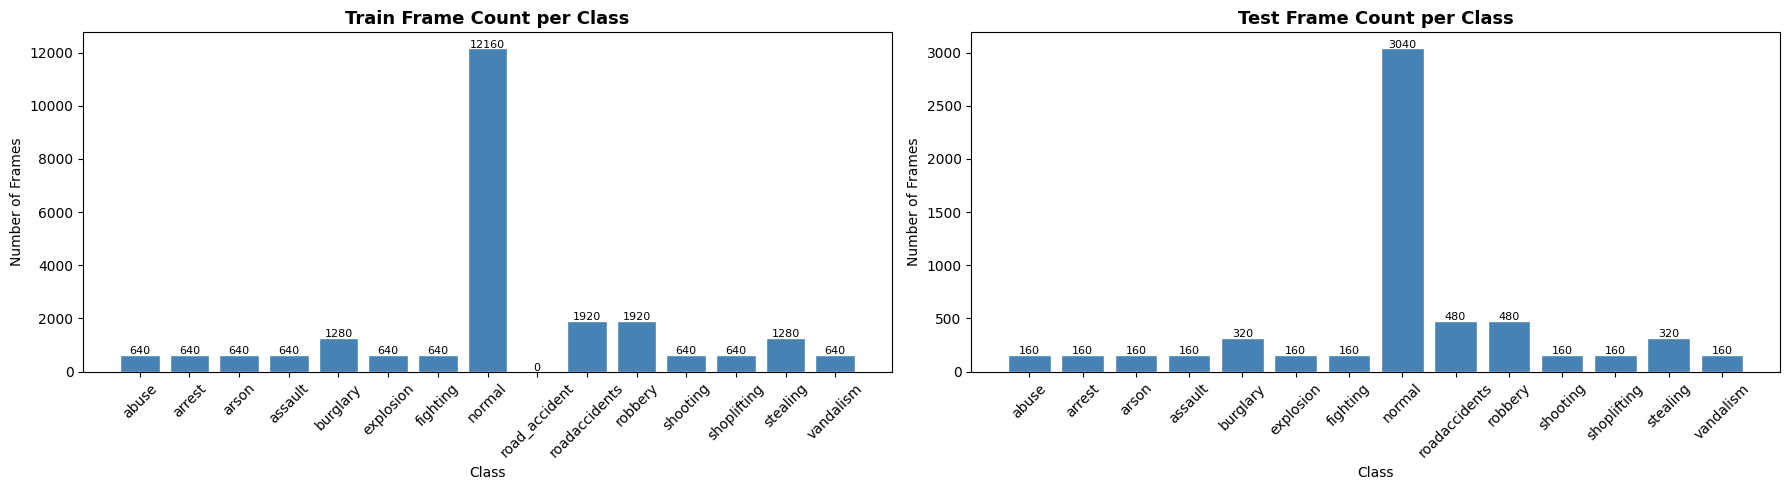

Train: {'abuse': 640, 'arrest': 640, 'arson': 640, 'assault': 640, 'burglary': 1280, 'explosion': 640, 'fighting': 640, 'normal': 12160, 'road_accident': 0, 'roadaccidents': 1920, 'robbery': 1920, 'shooting': 640, 'shoplifting': 640, 'stealing': 1280, 'vandalism': 640}
Test:  {'abuse': 160, 'arrest': 160, 'arson': 160, 'assault': 160, 'burglary': 320, 'explosion': 160, 'fighting': 160, 'normal': 3040, 'roadaccidents': 480, 'robbery': 480, 'shooting': 160, 'shoplifting': 160, 'stealing': 320, 'vandalism': 160}


In [11]:
# ── Verify frame extraction & visualize class distribution ────────────────
def count_frames_per_class(split: str) -> dict:
    counts = {}
    split_dir = Path(CFG.FRAMES_DIR) / split
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir():
            counts[cls_dir.name] = len(list(cls_dir.glob('*.jpg')))
    return counts

train_counts = count_frames_per_class('train')
test_counts  = count_frames_per_class('test')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Train Frame Count per Class', 'Test Frame Count per Class']):
    ax.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Number of Frames')
    ax.tick_params(axis='x', rotation=45)
    for i, (k, v) in enumerate(counts.items()):
        ax.text(i, v + 5, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print('Train:', train_counts)
print('Test: ', test_counts)

In [13]:
# ── ImageNet normalization stats ───────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Augmentation pipelines ────────────────────────────────────────────────
# ── Augmentation pipelines ────────────────────────────────────────────────
train_transforms = A.Compose([
    A.RandomResizedCrop(size=(CFG.IMG_SIZE, CFG.IMG_SIZE), scale=(0.7, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1, p=0.6),
    A.Rotate(limit=15, p=0.4),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(height=CFG.IMG_SIZE, width=CFG.IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

print('Augmentation pipelines ready.')

Augmentation pipelines ready.


In [14]:
class CCTVFrameDataset(Dataset):
    """
    Frame-level dataset.
    Each item is a single frame (not a full video).
    Training is done at frame level; inference aggregates across frames.
    """
    def __init__(self, split: str, transform=None):
        """
        Args:
            split     : 'train' or 'test'
            transform : albumentations transform pipeline
        """
        self.transform   = transform
        self.samples     = []   # List of (frame_path, label_idx)
        self.class_names = CFG.CLASS_NAMES

        split_dir = Path(CFG.FRAMES_DIR) / split
        for cls_dir in sorted(split_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            label_name = cls_dir.name
            if label_name not in CFG.CLASS_TO_IDX:
                print(f'Unknown class folder: {label_name} — skipping')
                continue
            label_idx = CFG.CLASS_TO_IDX[label_name]
            for frame_path in sorted(cls_dir.glob('*.jpg')):
                self.samples.append((str(frame_path), label_idx))

        print(f'[{split}] Dataset: {len(self.samples)} frames across {len(set(s[1] for s in self.samples))} classes')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_path, label = self.samples[idx]
        image = cv2.imread(frame_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0

        return image, label

    def get_class_weights(self) -> torch.Tensor:
        """Compute inverse-frequency class weights for weighted loss."""
        label_counts = Counter(label for _, label in self.samples)
        total = len(self.samples)
        weights = torch.zeros(CFG.NUM_CLASSES)
        for cls_idx, count in label_counts.items():
            weights[cls_idx] = total / (CFG.NUM_CLASSES * count)
        return weights

    def get_sample_weights(self) -> list:
        """Per-sample weights for WeightedRandomSampler (balances batches)."""
        class_weights = self.get_class_weights()
        return [class_weights[label].item() for _, label in self.samples]

In [15]:
# ── Build datasets ────────────────────────────────────────────────────────
train_dataset = CCTVFrameDataset(split='train', transform=train_transforms)
test_dataset  = CCTVFrameDataset(split='test',  transform=val_transforms)

# ── Weighted sampler to handle class imbalance in batches ─────────────────
sample_weights = train_dataset.get_sample_weights()
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ── Compute class weights for loss function ───────────────────────────────
class_weights = train_dataset.get_class_weights().to(DEVICE)
print(f'\nClass weights (for loss):')
for i, (cls, w) in enumerate(zip(CFG.CLASS_NAMES, class_weights.cpu())):
    print(f'  {cls:<18}: {w:.3f}')

# ── Data loaders ──────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    sampler=sampler,          # Use weighted sampler instead of shuffle=True
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

print(f'\nDataLoaders ready.')
print(f'   Train batches : {len(train_loader)}')
print(f'   Test  batches : {len(test_loader)}')

Unknown class folder: roadaccidents — skipping
[train] Dataset: 22400 frames across 13 classes
Unknown class folder: roadaccidents — skipping
[test] Dataset: 5600 frames across 13 classes

Class weights (for loss):
  abuse             : 2.500
  arrest            : 2.500
  arson             : 2.500
  assault           : 2.500
  burglary          : 1.250
  explosion         : 2.500
  fighting          : 2.500
  normal            : 0.132
  road_accident     : 0.000
  robbery           : 0.833
  shooting          : 2.500
  shoplifting       : 2.500
  stealing          : 1.250
  vandalism         : 2.500

DataLoaders ready.
   Train batches : 700
   Test  batches : 175


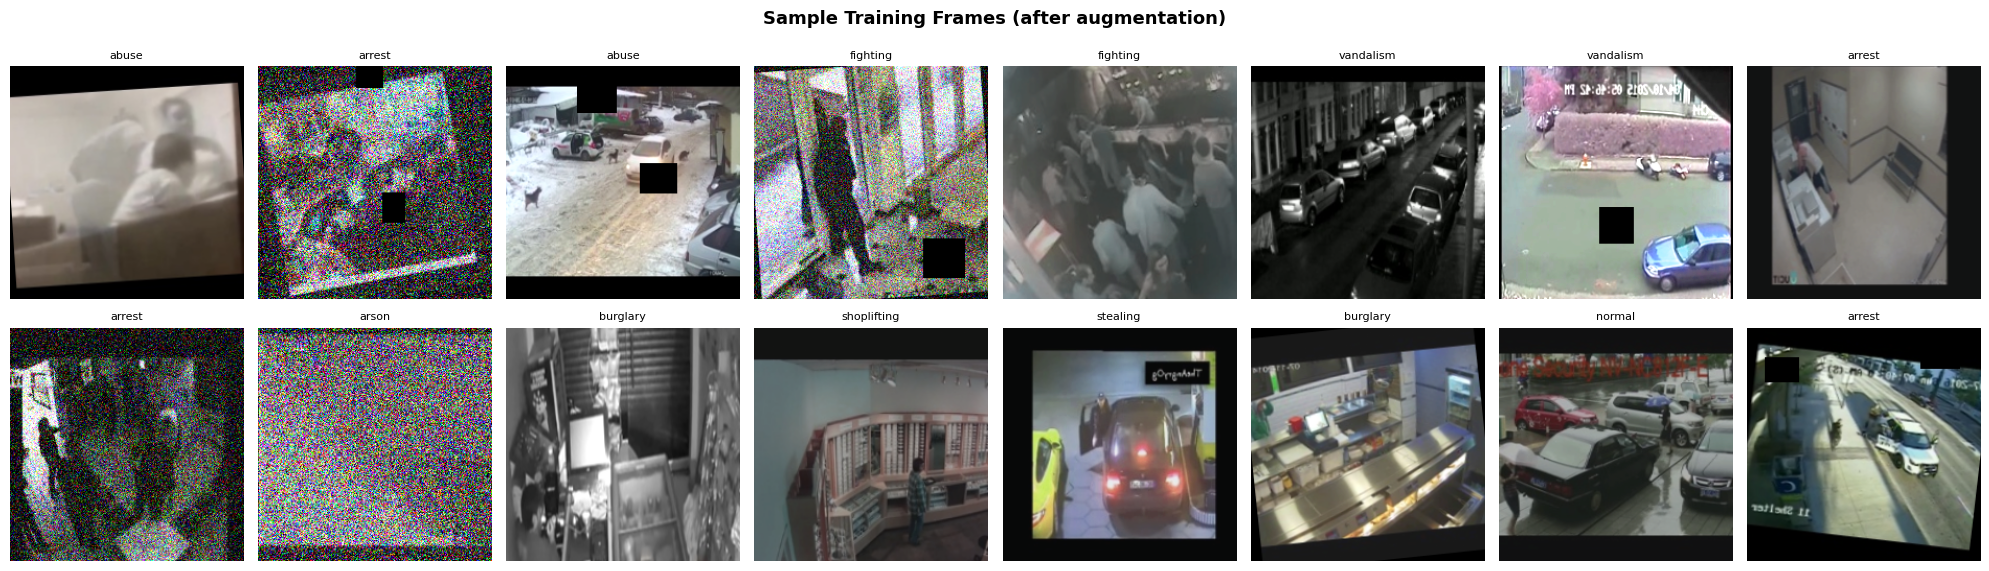

In [16]:
# ── Visualize a batch of training frames ──────────────────────────────────
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flat):
    if i >= 16: break
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CFG.IDX_TO_CLASS[labels[i].item()], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Frames (after augmentation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
class ResNeXt50Classifier(nn.Module):
    """
    ResNeXt-50 (32x4d) backbone with a custom classification head.
    Supports 3-phase training:
      Phase 1 — freeze backbone, train head only
      Phase 2 — unfreeze last 2 layers + head
      Phase 3 — unfreeze all
    """
    def __init__(self, num_classes: int = CFG.NUM_CLASSES, dropout: float = CFG.DROPOUT):
        super().__init__()

        # Load pretrained ResNeXt-50 (32x4d)
        backbone = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

        # Feature extractor (everything except the final FC layer)
        self.features = nn.Sequential(*list(backbone.children())[:-2])  # up to last conv block
        self.pool     = nn.AdaptiveAvgPool2d(1)   # Global Average Pooling → (B, 2048, 1, 1)

        # Custom classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75),
            nn.Linear(512, num_classes)
        )

        # Start with backbone frozen
        self.freeze_backbone()

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x   # Raw logits (CrossEntropyLoss handles softmax internally)

    # ── Freezing helpers ──────────────────────────────────────────────────
    def freeze_backbone(self):
        """Phase 1: Only train the classification head."""
        for param in self.features.parameters():
            param.requires_grad = False
        print('Backbone frozen — training head only.')

    def unfreeze_last_layers(self, n_blocks: int = 2):
        """Phase 2: Unfreeze last N blocks of the backbone."""
        # features[-n_blocks:] correspond to layer3, layer4 in ResNeXt
        all_blocks = list(self.features.children())
        for block in all_blocks[-n_blocks:]:
            for param in block.parameters():
                param.requires_grad = True
        print(f'Last {n_blocks} backbone blocks + head unfrozen.')

    def unfreeze_all(self):
        """Phase 3: Unfreeze entire model."""
        for param in self.parameters():
            param.requires_grad = True
        print('All layers unfrozen.')

    def count_trainable_params(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'   Trainable params : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')


# Instantiate model
model = ResNeXt50Classifier(num_classes=CFG.NUM_CLASSES, dropout=CFG.DROPOUT).to(DEVICE)
model.count_trainable_params()

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 243MB/s]


Backbone frozen — training head only.
   Trainable params : 1,056,270 / 24,036,174 (4.4%)


In [18]:
# ── Training & Validation step functions ──────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='  Train', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        # Mixed precision forward pass
        with torch.cuda.amp.autocast():
            logits = model(images)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc='  Val  ', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.cuda.amp.autocast():
            logits = model(images)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels


def save_checkpoint(model, optimizer, epoch, val_loss, path):
    torch.save({
        'epoch'       : epoch,
        'model_state' : model.state_dict(),
        'optim_state' : optimizer.state_dict(),
        'val_loss'    : val_loss
    }, path)


print('Training utilities defined.')

Training utilities defined.


In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PHASE 1 — Warm-up: Train classification head only
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('=' * 60)
print('PHASE 1 — Warm-up Training')
print('=' * 60)

model.freeze_backbone()
model.count_trainable_params()

criterion  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer  = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                         lr=CFG.WARMUP_LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.WARMUP_EPOCHS)
scaler     = torch.cuda.amp.GradScaler()

history_warmup = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')

for epoch in range(1, CFG.WARMUP_EPOCHS + 1):
    print(f'\nEpoch [{epoch}/{CFG.WARMUP_EPOCHS}]  LR: {scheduler.get_last_lr()[0]:.2e}')

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss, val_acc, _, _ = validate(model, test_loader, criterion)
    scheduler.step()

    history_warmup['train_loss'].append(train_loss)
    history_warmup['val_loss'].append(val_loss)
    history_warmup['train_acc'].append(train_acc)
    history_warmup['val_acc'].append(val_acc)

    print(f'  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}')
    print(f'  Val   Loss: {val_loss:.4f}  Val   Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, optimizer, epoch, val_loss,
                        f'{CFG.CHECKPOINT_DIR}/best_warmup.pth')
        print('Checkpoint saved.')

print('\nWarm-up complete.')

PHASE 1 — Warm-up Training
Backbone frozen — training head only.
   Trainable params : 1,056,270 / 24,036,174 (4.4%)

Epoch [1/8]  LR: 1.00e-03


  Train:   0%|          | 0/700 [00:00<?, ?it/s]

  Val  :   0%|          | 0/175 [00:00<?, ?it/s]

  Train Loss: 2.0225  Train Acc: 0.2938
  Val   Loss: 5.6771  Val   Acc: 0.1121
Checkpoint saved.

Epoch [2/8]  LR: 9.62e-04


  Train:   0%|          | 0/700 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/175 [00:00<?, ?it/s]

  Train Loss: 1.4249  Train Acc: 0.5502
  Val   Loss: 5.2725  Val   Acc: 0.1355
Checkpoint saved.

Epoch [8/8]  LR: 3.81e-05


  Train:   0%|          | 0/700 [00:00<?, ?it/s]

  Val  :   0%|          | 0/175 [00:00<?, ?it/s]

  Train Loss: 1.4198  Train Acc: 0.5529
  Val   Loss: 5.3557  Val   Acc: 0.1363

Warm-up complete.


In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PHASE 2 — Fine-tune: Unfreeze last 2 backbone blocks + head
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('=' * 60)
print('PHASE 2 — Fine-tuning')
print('=' * 60)

model.unfreeze_last_layers(n_blocks=2)
model.count_trainable_params()

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=CFG.FINETUNE_LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.FINETUNE_EPOCHS)

history_finetune = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(1, CFG.FINETUNE_EPOCHS + 1):
    print(f'\nEpoch [{epoch}/{CFG.FINETUNE_EPOCHS}]  LR: {scheduler.get_last_lr()[0]:.2e}')

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss, val_acc, _, _ = validate(model, test_loader, criterion)
    scheduler.step()

    history_finetune['train_loss'].append(train_loss)
    history_finetune['val_loss'].append(val_loss)
    history_finetune['train_acc'].append(train_acc)
    history_finetune['val_acc'].append(val_acc)

    print(f'  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}')
    print(f'  Val   Loss: {val_loss:.4f}  Val   Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, optimizer, epoch, val_loss,
                        f'{CFG.CHECKPOINT_DIR}/best_finetune.pth')
        print('Checkpoint saved.')

print('\nFine-tuning complete.')

PHASE 2 — Fine-tuning
Last 2 backbone blocks + head unfrozen.
   Trainable params : 22,623,758 / 24,036,174 (94.1%)

Epoch [1/20]  LR: 1.00e-04


  Train:   0%|          | 0/700 [00:00<?, ?it/s]

  Val  :   0%|          | 0/175 [00:00<?, ?it/s]

  Train Loss: 0.7293  Train Acc: 0.8638
  Val   Loss: 4.4090  Val   Acc: 0.2761
Checkpoint saved.

Epoch [2/20]  LR: 9.94e-05


  Train:   0%|          | 0/700 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/175 [00:00<?, ?it/s]

  Train Loss: 0.5496  Train Acc: 0.9646
  Val   Loss: 4.0181  Val   Acc: 0.5971

Epoch [20/20]  LR: 6.16e-07


  Train:   0%|          | 0/700 [00:00<?, ?it/s]

  Val  :   0%|          | 0/175 [00:00<?, ?it/s]

  Train Loss: 0.5508  Train Acc: 0.9659
  Val   Loss: 4.0173  Val   Acc: 0.5984

Fine-tuning complete.


In [22]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PHASE 3 — Full Fine-tune (optional): Unfreeze all layers
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('=' * 60)
print('PHASE 3 — Full Fine-tuning (all layers)')
print('=' * 60)

model.unfreeze_all()
model.count_trainable_params()

optimizer = optim.AdamW(model.parameters(),
                        lr=CFG.FULL_FT_LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.FULL_FT_EPOCHS)

history_fullft = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')

for epoch in range(1, CFG.FULL_FT_EPOCHS + 1):
    print(f'\nEpoch [{epoch}/{CFG.FULL_FT_EPOCHS}]  LR: {scheduler.get_last_lr()[0]:.2e}')

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss, val_acc, _, _ = validate(model, test_loader, criterion)
    scheduler.step()

    history_fullft['train_loss'].append(train_loss)
    history_fullft['val_loss'].append(val_loss)
    history_fullft['train_acc'].append(train_acc)
    history_fullft['val_acc'].append(val_acc)

    print(f'  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}')
    print(f'  Val   Loss: {val_loss:.4f}  Val   Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, optimizer, epoch, val_loss,
                        f'{CFG.CHECKPOINT_DIR}/best_fullft.pth')
        print('Checkpoint saved.')

print('\nFull fine-tuning complete.')

PHASE 3 — Full Fine-tuning (all layers)
All layers unfrozen.
   Trainable params : 24,036,174 / 24,036,174 (100.0%)

Epoch [1/8]  LR: 1.00e-05


  Train:   0%|          | 0/700 [00:00<?, ?it/s]

  Val  :   0%|          | 0/175 [00:00<?, ?it/s]

  Train Loss: 0.5512  Train Acc: 0.9661
  Val   Loss: 4.0224  Val   Acc: 0.5929
Checkpoint saved.

Epoch [2/8]  LR: 9.62e-06


  Train:   0%|          | 0/700 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/175 [00:00<?, ?it/s]

  Train Loss: 0.5453  Train Acc: 0.9684
  Val   Loss: 4.0154  Val   Acc: 0.5962

Epoch [8/8]  LR: 3.81e-07


  Train:   0%|          | 0/700 [00:00<?, ?it/s]

  Val  :   0%|          | 0/175 [00:00<?, ?it/s]

  Train Loss: 0.5445  Train Acc: 0.9692
  Val   Loss: 4.0130  Val   Acc: 0.5995

Full fine-tuning complete.


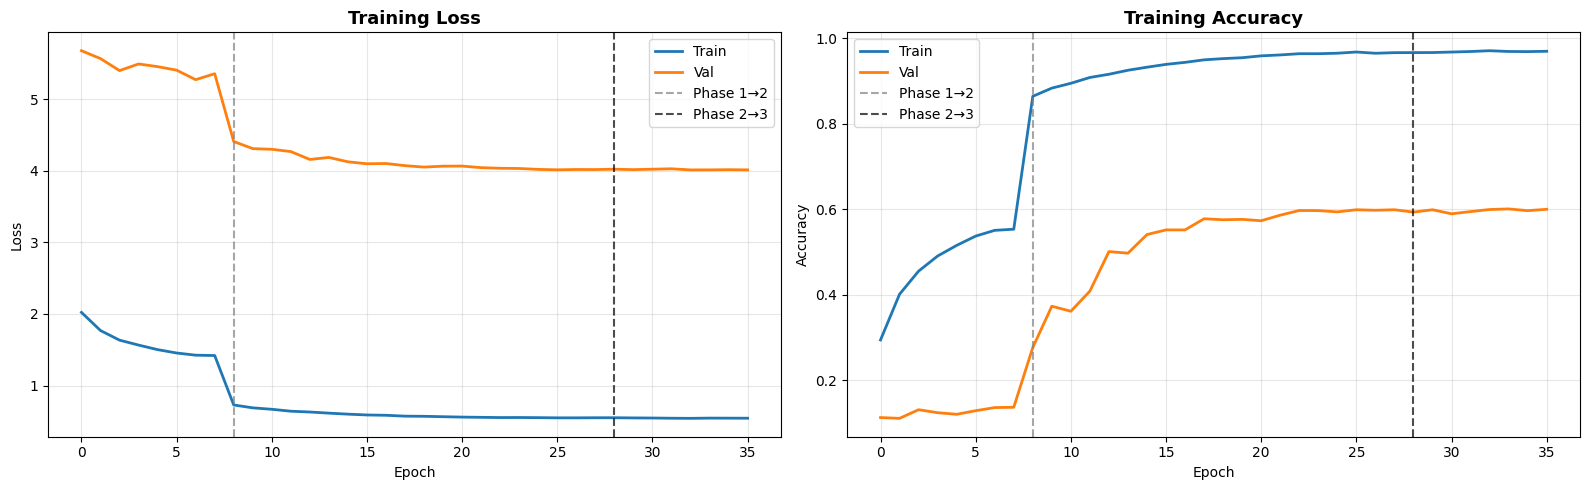

In [23]:
# ── Plot all training phases ───────────────────────────────────────────────
def merge_history(*histories):
    merged = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for h in histories:
        for k in merged:
            merged[k].extend(h[k])
    return merged

full_history = merge_history(history_warmup, history_finetune, history_fullft)

# Phase boundary lines
p1_end = CFG.WARMUP_EPOCHS
p2_end = CFG.WARMUP_EPOCHS + CFG.FINETUNE_EPOCHS

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric, title in zip(axes,
                              [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
                              ['Loss', 'Accuracy']):
    ax.plot(full_history[metric[0]], label='Train', linewidth=2)
    ax.plot(full_history[metric[1]], label='Val',   linewidth=2)
    ax.axvline(p1_end, color='gray',  linestyle='--', alpha=0.7, label='Phase 1→2')
    ax.axvline(p2_end, color='black', linestyle='--', alpha=0.7, label='Phase 2→3')
    ax.set_title(f'Training {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# ── Load best checkpoint for evaluation ───────────────────────────────────
best_ckpt_path = f'{CFG.CHECKPOINT_DIR}/best_fullft.pth'
checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded best model from epoch {checkpoint["epoch"]}  (val_loss={checkpoint["val_loss"]:.4f})')

Loaded best model from epoch 5  (val_loss=4.0125)


In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Find which classes actually appear in test set
present_labels = sorted(set(all_labels) | set(all_preds))
present_names  = [CFG.IDX_TO_CLASS[i] for i in present_labels]

# Check which class is missing
all_label_names = set(CFG.CLASS_NAMES)
present_set     = set(present_names)
missing         = all_label_names - present_set
print(f'⚠️  Missing class(es) from test set: {missing}')

print(f'\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print('\n' + '=' * 60)
print('Per-Class Classification Report')
print('=' * 60)
print(classification_report(
    all_labels, all_preds,
    labels=present_labels,        # ← only evaluate on classes that exist
    target_names=present_names,   # ← matching names for those labels
    digits=3,
    zero_division=0
))

⚠️  Missing class(es) from test set: {'road_accident'}

Test Accuracy: 0.5989 (59.89%)

Per-Class Classification Report
              precision    recall  f1-score   support

       abuse      0.096     0.044     0.060       160
      arrest      0.103     0.150     0.122       160
       arson      0.253     0.388     0.306       160
     assault      0.010     0.006     0.008       160
    burglary      0.288     0.209     0.242       320
   explosion      0.402     0.306     0.348       160
    fighting      0.206     0.138     0.165       160
      normal      0.770     0.894     0.827      3040
     robbery      0.466     0.456     0.461       480
    shooting      0.000     0.000     0.000       160
 shoplifting      0.420     0.231     0.298       160
    stealing      0.547     0.416     0.472       320
   vandalism      0.139     0.100     0.116       160

    accuracy                          0.599      5600
   macro avg      0.285     0.257     0.264      5600
weighted avg  

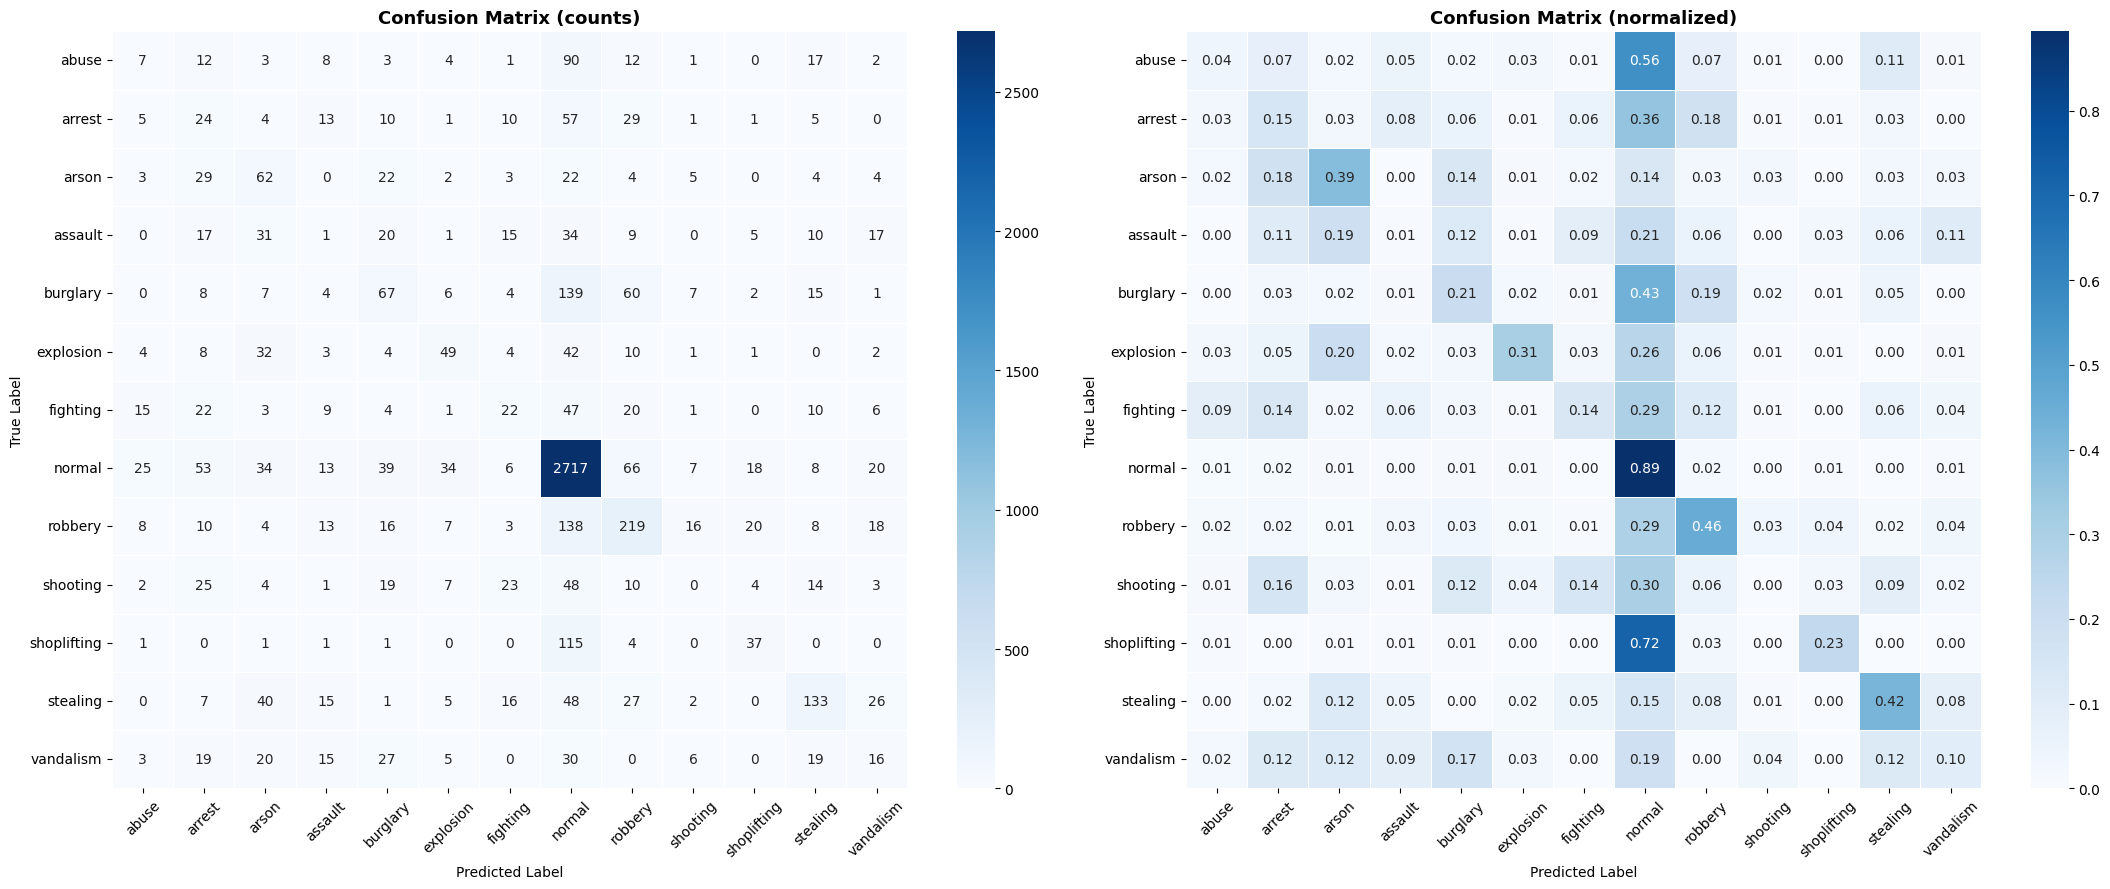

In [27]:
cm      = confusion_matrix(all_labels, all_preds, labels=present_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalized)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=present_names,   # ← use present_names
        yticklabels=present_names,
        ax=ax, linewidths=0.5
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [28]:
@torch.no_grad()
def predict_video(video_path: str, model: nn.Module, num_frames: int = CFG.NUM_FRAMES,
                  top_k: int = 3) -> dict:
    """
    Full inference pipeline for a single video.

    Steps:
      1. Extract `num_frames` evenly-spaced frames
      2. Preprocess each frame
      3. Run through ResNeXt-50
      4. Average softmax probabilities across all frames
      5. Return predicted class + confidence + top-k breakdown

    Args:
        video_path : path to input video file
        model      : trained ResNeXt50Classifier
        num_frames : number of frames to sample
        top_k      : return top-k class probabilities

    Returns:
        dict with keys: predicted_class, confidence, top_k_predictions, per_frame_preds
    """
    model.eval()

    # Step 1 — Extract frames
    frames = extract_frames(video_path, num_frames=num_frames)
    if not frames:
        return {'error': f'Could not extract frames from {video_path}'}

    # Step 2 — Preprocess frames
    batch_tensors = []
    for frame in frames:
        augmented = val_transforms(image=frame)
        batch_tensors.append(augmented['image'])

    batch = torch.stack(batch_tensors).to(DEVICE)   # (num_frames, 3, 224, 224)

    # Step 3 — Forward pass
    with torch.cuda.amp.autocast():
        logits = model(batch)                        # (num_frames, num_classes)

    # Step 4 — Softmax per frame, then average
    probs_per_frame  = torch.softmax(logits, dim=1)  # (num_frames, num_classes)
    avg_probs        = probs_per_frame.mean(dim=0)   # (num_classes,)

    # Step 5 — Decode prediction
    top_k_vals, top_k_idxs = torch.topk(avg_probs, k=top_k)
    predicted_idx   = top_k_idxs[0].item()
    confidence      = top_k_vals[0].item()

    # Per-frame predictions (useful for temporal analysis)
    frame_preds = [CFG.IDX_TO_CLASS[i] for i in probs_per_frame.argmax(dim=1).cpu().tolist()]

    return {
        'predicted_class'  : CFG.IDX_TO_CLASS[predicted_idx],
        'confidence'       : round(confidence * 100, 2),
        'top_k_predictions': [
            {'class': CFG.IDX_TO_CLASS[idx.item()], 'confidence': round(val.item() * 100, 2)}
            for val, idx in zip(top_k_vals, top_k_idxs)
        ],
        'per_frame_preds'  : frame_preds,
        'frames_sampled'   : len(frames)
    }


print('Inference function ready.')

Inference function ready.


In [35]:
# ── Run inference on a sample video ───────────────────────────────────────
# Replace with an actual video path from your dataset
sample_video = '/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/vandalism/Vandalism007_x264.mp4'   # ← change this path

result = predict_video(sample_video, model, top_k=3)

if 'error' not in result:
    print(f'\nVideo: {sample_video}')
    print(f'   Frames sampled : {result["frames_sampled"]}')
    print(f'\nPredicted Class : {result["predicted_class"].upper()}')
    print(f'   Confidence      : {result["confidence"]}%')
    print(f'\nTop-3 Predictions:')
    for i, pred in enumerate(result['top_k_predictions'], 1):
        bar = '█' * int(pred['confidence'] / 3)
        print(f'   {i}. {pred["class"]:<18} {pred["confidence"]:>6.2f}%  {bar}')
    print(f'\n  Per-frame predictions:')
    print(f'   {result["per_frame_preds"]}')
else:
    print(result['error'])


Video: /kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/vandalism/Vandalism007_x264.mp4
   Frames sampled : 16

Predicted Class : VANDALISM
   Confidence      : 94.14%

Top-3 Predictions:
   1. vandalism           94.14%  ███████████████████████████████
   2. arrest               0.68%  
   3. fighting             0.66%  

  Per-frame predictions:
   ['vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism', 'vandalism']


In [41]:
# ── Batch inference on a folder of videos ─────────────────────────────────
def batch_inference(video_dir: str, model: nn.Module) -> pd.DataFrame:
    """
    Run inference on all .mp4 / .avi files in a directory.
    Returns a DataFrame with filename, predicted_class, confidence.
    """
    video_dir  = Path(video_dir)
    video_files = list(video_dir.glob('**/*.mp4')) + list(video_dir.glob('**/*.avi'))
    results = []

    for vf in tqdm(video_files, desc='Batch inference'):
        res = predict_video(str(vf), model)
        if 'error' not in res:
            results.append({
                'filename'       : vf.name,
                'predicted_class': res['predicted_class'],
                'confidence'     : res['confidence'],
                'top2_class'     : res['top_k_predictions'][1]['class'],
                'top2_conf'      : res['top_k_predictions'][1]['confidence']
            })
        else:
            results.append({'filename': vf.name, 'predicted_class': 'ERROR',
                            'confidence': 0, 'top2_class': '', 'top2_conf': 0})

    df = pd.DataFrame(results)
    return df


#Example: Run on all videos in a folder
inference_df = batch_inference('/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/shoplifting', model)
inference_df.to_csv('./inference_results.csv', index=False)
display(inference_df.head(20))
print('Batch inference function ready — uncomment the lines above to run.')

Batch inference:   0%|          | 0/50 [00:00<?, ?it/s]

,filename,predicted_class,confidence,top2_class,top2_conf
0,Shoplifting020_x264.mp4,shoplifting,94.68,arson,0.62
1,Shoplifting055_x264.mp4,shoplifting,83.11,assault,3.02
2,Shoplifting045_x264.mp4,shoplifting,93.16,arson,0.82
3,Shoplifting042_x264.mp4,shoplifting,95.17,explosion,0.54
4,Shoplifting005_x264.mp4,shoplifting,92.68,fighting,0.89
5,Shoplifting043_x264.mp4,shoplifting,46.85,normal,10.36
6,Shoplifting048_x264.mp4,shoplifting,93.36,fighting,0.76
7,Shoplifting028_x264.mp4,shoplifting,91.89,arrest,2.94
8,Shoplifting003_x264.mp4,normal,52.25,shoplifting,7.58
9,Shoplifting034_x264.mp4,shoplifting,93.85,arrest,0.71


Batch inference function ready — uncomment the lines above to run.


In [42]:
# ── Visualize sampled frames with per-frame predictions ───────────────────
def visualize_inference(video_path: str, model: nn.Module):
    frames = extract_frames(video_path, num_frames=CFG.NUM_FRAMES)
    result = predict_video(video_path, model)

    if not frames or 'error' in result:
        print('Could not process video.')
        return

    n = len(frames)
    cols = 8
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))

    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i < n:
            ax.imshow(frames[i])
            ax.set_title(result['per_frame_preds'][i], fontsize=7,
                         color='red' if result['per_frame_preds'][i] != result['predicted_class'] else 'green')

    plt.suptitle(
        f'Prediction: {result["predicted_class"].upper()}  |  '
        f'Confidence: {result["confidence"]}%\n'
        f'Path: {Path(video_path).name}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# Example
# visualize_inference('./data/fighting/Fighting001_x264.mp4', model)
print('Visualization function ready — call visualize_inference(video_path, model) to use.')

Visualization function ready — call visualize_inference(video_path, model) to use.


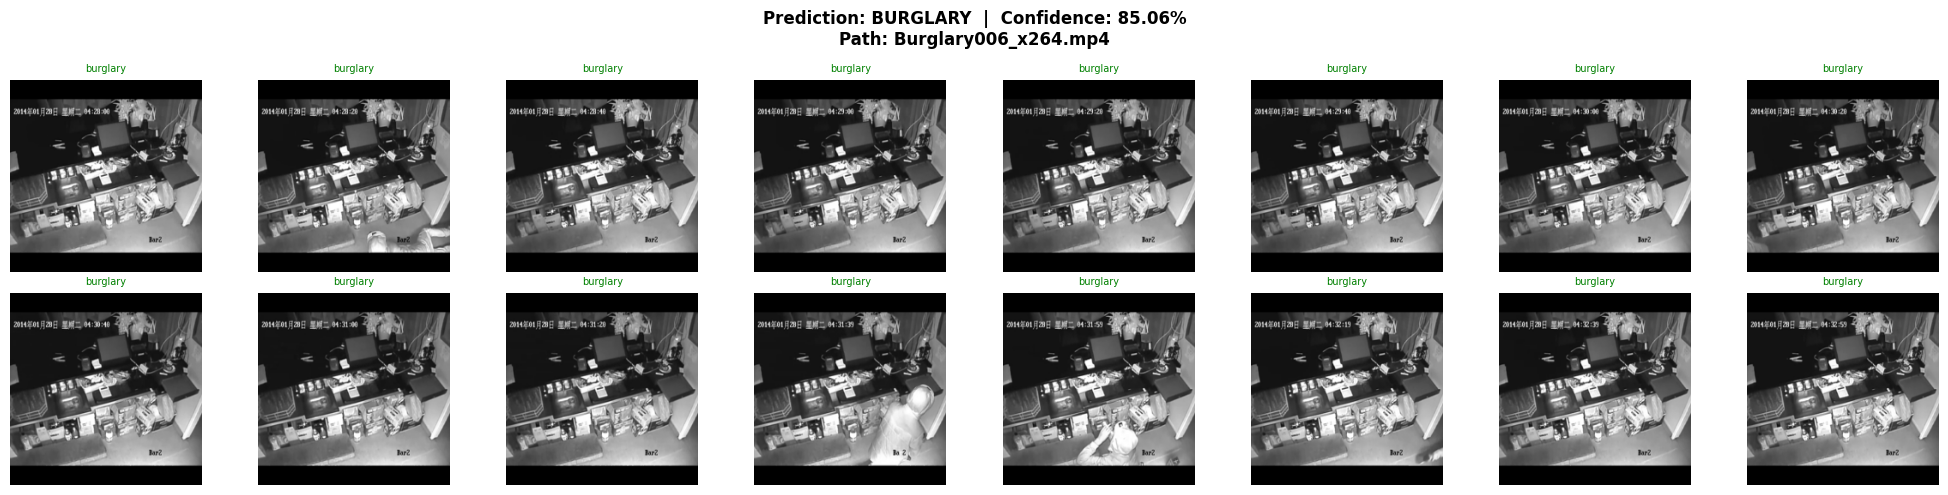

In [43]:
video_path = "/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/burglary/Burglary006_x264.mp4"
visualize_inference(video_path, model)

In [44]:
import shutil
import os
from IPython.display import FileLink, display

# ── 1. Model Checkpoint ───────────────────────────────────────────────────
shutil.copy('/kaggle/working/checkpoints/best_fullft.pth',
            '/kaggle/working/resnext50_cctv_anomaly.pth')

# ── 2. Save inference.py ──────────────────────────────────────────────────
inference_code = '''
import cv2
import torch
import torch.nn as nn
import numpy as np
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_FRAMES  = 16
IMG_SIZE    = 224
NUM_CLASSES = 14

CLASS_NAMES = [
    "abuse", "arrest", "arson", "assault", "burglary",
    "explosion", "fighting", "normal", "road_accident",
    "robbery", "shooting", "shoplifting", "stealing", "vandalism"
]
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASS_NAMES)}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

class ResNeXt50Classifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        backbone        = models.resnext50_32x4d(weights=None)
        self.features   = nn.Sequential(*list(backbone.children())[:-2])
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

def load_model(checkpoint_path):
    model = ResNeXt50Classifier().to(DEVICE)
    ckpt  = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    print(f"Model loaded from: {checkpoint_path}")
    return model

def extract_frames(video_path, num_frames=NUM_FRAMES):
    cap     = cv2.VideoCapture(video_path)
    total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, num_frames, dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

@torch.no_grad()
def predict(video_path, model, top_k=3):
    frames    = extract_frames(video_path)
    tensors   = [transform(image=f)["image"] for f in frames]
    batch     = torch.stack(tensors).to(DEVICE)
    avg_probs = torch.softmax(model(batch), dim=1).mean(0)
    top_vals, top_idxs = torch.topk(avg_probs, k=top_k)
    return {
        "predicted_class" : IDX_TO_CLASS[top_idxs[0].item()],
        "confidence"      : round(top_vals[0].item() * 100, 2),
        "top_k"           : [
            {"class": IDX_TO_CLASS[i.item()], "confidence": round(v.item() * 100, 2)}
            for v, i in zip(top_vals, top_idxs)
        ]
    }

if __name__ == "__main__":
    import sys
    model  = load_model("resnext50_cctv_anomaly.pth")
    video  = sys.argv[1] if len(sys.argv) > 1 else "sample.mp4"
    result = predict(video, model)
    print(f"Prediction : {result['predicted_class'].upper()}")
    print(f"Confidence : {result['confidence']}%")
    for r in result["top_k"]:
        print(f"  {r['class']:<18} {r['confidence']:>6.2f}%")
'''

with open('/kaggle/working/inference.py', 'w') as f:
    f.write(inference_code)

# ── 3. Save class names + label mapping as JSON ───────────────────────────
import json

metadata = {
    'class_names'  : CFG.CLASS_NAMES,
    'class_to_idx' : CFG.CLASS_TO_IDX,
    'idx_to_class' : {str(k): v for k, v in CFG.IDX_TO_CLASS.items()},
    'num_classes'  : CFG.NUM_CLASSES,
    'img_size'     : CFG.IMG_SIZE,
    'num_frames'   : CFG.NUM_FRAMES,
}
with open('/kaggle/working/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# ── 4. Zip everything into one download ───────────────────────────────────
files_to_zip = {
    'resnext50_cctv_anomaly.pth' : '/kaggle/working/resnext50_cctv_anomaly.pth',
    'inference.py'               : '/kaggle/working/inference.py',
    'model_metadata.json'        : '/kaggle/working/model_metadata.json',
}

# Verify all files exist
print('📦 Files to be zipped:')
for name, path in files_to_zip.items():
    size = os.path.getsize(path) / (1024 * 1024)
    print(f'  ✅ {name:<35} {size:.2f} MB')

# Create zip
shutil.make_archive('/kaggle/working/cctv_anomaly_model', 'zip', 
                    '/kaggle/working',
                    )

zip_size = os.path.getsize('/kaggle/working/cctv_anomaly_model.zip') / (1024 * 1024)
print(f'\n✅ ZIP created: cctv_anomaly_model.zip  ({zip_size:.2f} MB)')

# ── 5. Download links ─────────────────────────────────────────────────────
print('\n🔗 Download links:')
display(FileLink('cctv_anomaly_model.zip'))          # Full zip
display(FileLink('resnext50_cctv_anomaly.pth'))      # Model only
display(FileLink('inference.py'))                    # Inference script only
display(FileLink('model_metadata.json'))             # Metadata only

📦 Files to be zipped:
  ✅ resnext50_cctv_anomaly.pth          275.57 MB
  ✅ inference.py                        0.00 MB
  ✅ model_metadata.json                 0.00 MB

✅ ZIP created: cctv_anomaly_model.zip  (1432.99 MB)

🔗 Download links:


/kaggle/working/cctv_anomaly_model.zip

/kaggle/working/resnext50_cctv_anomaly.pth

/kaggle/working/inference.py

/kaggle/working/model_metadata.json